# GLU vs. GRSU vs. ALMM

In [ ]:
# Import necessary packages and libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
import graphlearning as gl
from scipy.special import jn
import scipy.sparse as sps
import scipy.sparse.linalg as spla
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.ndimage import gaussian_filter
from itertools import product
from joblib import Parallel, delayed
from scipy.optimize import nnls
from sklearn.decomposition import PCA

# Import functions from Chen et. al.
from graph_active_learning_functions import *

## Synthetic Linear Data

In [2]:
# Generate Random data
samples = 2000 # N
channels = 300 # p
np.random.seed(42)

# Create random labels and abundance matrix
L = np.random.uniform(0,1,samples)
A = np.array([L,1-L])

# Smooth out the two spectras
s_1 = gaussian_filter(np.random.uniform(0,1,channels),2)
s_2 = gaussian_filter(np.random.uniform(0,1,channels),2)

S_T = np.array([s_1,s_2])

S = S_T.T


# Create the linear mixing model
X=S@A
error_std = 0.05

E = np.random.normal(loc=0.0, scale=error_std, size=X.shape)

X=X+E

In [3]:
# GLU

# Pick best parameters
#alpha_vals = np.array([10, 20, 50, 100])
#lam_vals = np.sort(np.concatenate([10**np.arange(4), 5 * 10**np.arange(4)]))
#gamma_vals = 10.0 ** np.arange(-2, 3)
#rho_vals = 10.0 ** np.arange(-2, 3)

#best_params_GLU = parameter_testing(X, A, S, samples, 
                                #alpha_vals, lam_vals, gamma_vals, rho_vals, m_0 = 2,
                                #print_bool = False, GRSU_bool = False)

alpha_0 = 10
lam_0 = 1
gamma_0 = 0.01
rho_0 = 0.01

# Best RMSE + SAD: 23.875179751944458
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01

# Run algorithm on chosen parameters
A_f_GLU, S_f_GLU, A_rmse_GLU, S_sad_GLU = run_unmixing_pipeline_example(X, A, S, samples, 
                                                        alpha = alpha_0, lam = lam_0, gamma = gamma_0, rho = rho_0, m_0 = 2,
                                                        print_bool = True, GRSU_bool = False)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing...
Pipeline Complete!

Final Abundance Map Shape: (2, 2000)
Final End-member Matrix Shape: (300, 2)
Final Abundance RMSE: 21.39481515797743
Final Endmember SAD: 2.4803645939670274


In [4]:
# GRSU

# Pick best parameters
#best_params_GRSU = parameter_testing(X, A, S, samples, 
                                #alpha_vals, lam_vals, gamma_vals, rho_vals, m_0 = 2,
                                #print_bool = False, GRSU_bool = True)

alpha_0 = 10
lam_0 = 10
gamma_0 = 0.01
rho_0 = 0.01

# Best RMSE + SAD: 5.170721801379891
# Best alpha: 10
# Best lambda: 10
# Best gamma: 0.01
# Best rho: 0.01

# Run on best parameters
A_f_GRSU, S_f_GRSU, A_rmse_GRSU, S_sad_GRSU = run_unmixing_pipeline_example(X, A, S, samples, 
                                                        alpha = alpha_0, lam = lam_0, gamma = gamma_0, rho = rho_0, m_0 = 2,
                                                        print_bool = True, GRSU_bool = True)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing...
Pipeline Complete!

Final Abundance Map Shape: (2, 2000)
Final End-member Matrix Shape: (300, 2)
Final Abundance RMSE: 3.073787352255858
Final Endmember SAD: 2.0969344491240327


In [ ]:
# ALMM

alpha = 2e-4
beta = 2e-3
gamma = 5e-3
eta = 5e-3
maxIter = 50 # changed from 30

# Pick the best alpha
# best_rmse = np.inf
# best_alpha = None

# alpha_vals = [2e-3, 6e-4, 2e-4, 6e-5, 2e-5]

# for a in alpha_vals:

#     E_f, A_f, T_f, B_f = algo_2_almm(X, S, a, beta, gamma, eta, maxIter)

#     rmse = RMSE(A_f, A)  # Calculate RMSE
#     print(f"alpha={a:.6f} -> RMSE={rmse:.4f}")

#     if rmse < best_rmse:
#         best_rmse = rmse
#         best_alpha = a

# print(f"\nBest alpha: {best_alpha}, RMSE: {best_rmse:.4f}")

# alpha=0.002000 -> RMSE=19.5170
# alpha=0.000600 -> RMSE=11.6159
# alpha=0.000200 -> RMSE=9.9700
# alpha=0.000060 -> RMSE=12.6079
# alpha=0.000020 -> RMSE=13.9909

# Best alpha: 0.0002, RMSE: 9.9700

E_f_ALMM, A_f_ALMM, T_f_ALMM, B_f_ALMM = algo_2_almm(X, S, alpha, beta, gamma, eta, maxIter)

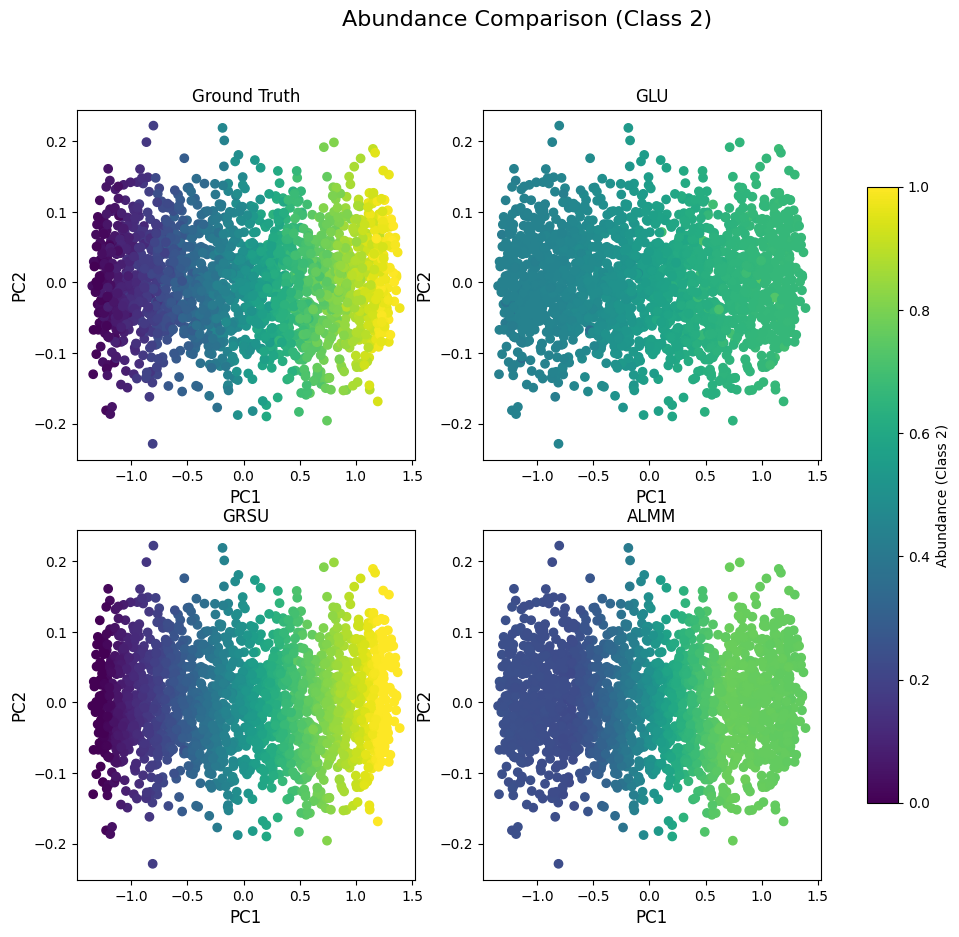

In [ ]:
## Plotting abundance maps

# Run PCA
pca1 = PCA(n_components=2)
X_pca1 = pca1.fit_transform(X.T)

# Visualizing
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#endmember_idx = 0  # which endmember/class you're visualizing

vmin, vmax = 0, 1  # fixed scale so colors are directly comparable across all 4 plots

# Top-left: Ground truth
sc1 = axes[0, 0].scatter(X_pca1[:,0], X_pca1[:,1], c=A[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[0, 0].set_title('Ground Truth')

# Top-right: GLU
sc2 = axes[0,1].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_GLU[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[0,1].set_title('GLU')

# Bottom-left: GRSU
sc3 = axes[1,0].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_GRSU[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[1,0].set_title('GRSU')

# Bottom-right: ALMM
sc4 = axes[1, 1].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_ALMM[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[1, 1].set_title('ALMM')

for ax in axes.flat:
    ax.set_xlabel('PC1', fontsize=12)
    ax.set_ylabel('PC2', fontsize=12)

fig.suptitle(f'Abundance Comparison (Class 2)', fontsize=16)

fig.colorbar(sc4, ax=axes, label=f'Abundance (Class 2)', shrink=0.8)

plt.show()

## Nonlinear Synthetic Data